# 📚 Section 7. Ratio Chart — Pie / Donut / Treemap
> 섹션 7. 비율 차트 — Pie / Donut / Treemap

---
# 🎯 Learning Objective · 학습 목표
Today I want to learn: · 오늘 배우고 싶은 것:
- [x] Build a Pie Chart and know why it stops working well past 5-6 slices  
Pie Chart를 만들고 조각이 5~6개를 넘으면 왜 효과가 떨어지는지 알기
- [x] Turn a Pie Chart into a Donut Chart and use the center space to display a KPI number  
Pie Chart를 Donut Chart로 바꾸고 중앙 공간에 KPI 숫자를 표시하기
- [x] Build a Treemap that encodes both size and a second variable (like growth rate) as color  
크기와 두 번째 변수(성장률 등)를 색상으로 함께 인코딩하는 Treemap 만들기

---
# 🧠 Concept · 개념

## What is it? · 무엇인가?

A Pie Chart treats the whole as 100% and represents each category's share as a wedge of a circle.

Pie Chart는 전체를 100%로 놓고, 각 범주가 차지하는 비중을 원의 부채꼴(wedge)로 표현하는 차트입니다.

## Why do we use it? · 왜 사용하는가?

Use it to emphasize each part's share of the whole, but only with a small number of categories (5-6 or fewer). Human eyes compare "length" far more accurately than "angle" or "area," so once you pass 3-4 wedges, judging which is bigger gets genuinely hard — for many-category or precision-sensitive cases, a Bar Chart (Section 4) is the more honest choice.

전체 대비 각 부분의 비중을 강조하고 싶을 때, 카테고리 개수가 적을 때(5~6개 이하) 사용합니다. 사람의 눈은 "각도"나 "넓이"보다 "길이"를 훨씬 정확하게 비교하기 때문에, 조각이 3~4개를 넘어가면 어느 게 더 큰지 판단하기 어려워집니다 — 카테고리가 많거나 정확한 비교가 중요하다면 Bar Chart(섹션 4)가 더 정직한 선택입니다.

## When is it used in Business Analytics? · 언제 비즈니스 분석에서 사용되는가?

DA/BA situations: sales channel composition, market share, survey response ratios.

DA/BA 실무 상황: 매출 채널 구성비, 시장 점유율, 설문 응답 비율.

| Situation / 상황 | Recommended / 추천 | Why / 이유 |
|---|---|---|
| 5 or fewer categories, simple share / 5개 이하, 단순 비중 강조 | Pie | Most widely recognized format / 가장 널리 알려진 형태 |
| 5 or fewer + want a KPI number visible too / 5개 이하 + 중앙에 총계·핵심 수치 강조 | Donut | Center space doubles as a KPI display / 중앙 여백을 KPI 표시 공간으로 활용 |
| 7+ categories, sizes vary a lot / 7개 이상, 크기 편차가 큼 | Treemap | Compares many categories by area, can add a 2nd variable via color / 많은 카테고리를 면적으로 비교, 색상으로 추가 지표까지 표현 가능 |

---
# 📝 Syntax · 문법

## Basic Syntax · 기본 문법

`ax.pie(values, labels=..., autopct=...)` draws the chart; `autopct='%1.1f%%'` auto-labels each wedge with its percentage to one decimal place.

`ax.pie(값, labels=..., autopct=...)`로 차트를 그리며, `autopct='%1.1f%%'`는 각 조각에 소수점 첫째 자리까지의 퍼센트를 자동으로 표시합니다.

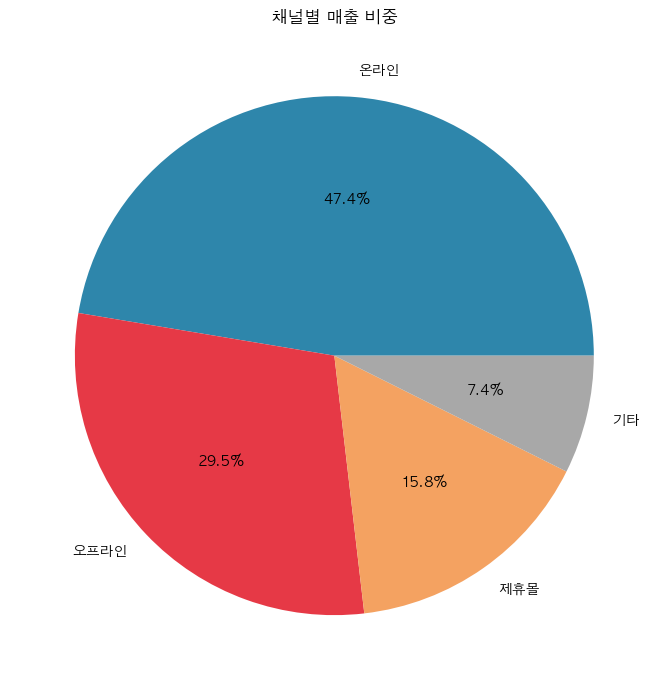

In [9]:
# Basic Syntax: a pie chart of channel sales share
# 기본 문법: 채널별 매출 비중 파이 차트

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

channels = ['온라인', '오프라인', '제휴몰', '기타']
sales = [450, 280, 150, 70]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sales, labels=channels, autopct='%1.1f%%',
       colors=['#2E86AB', '#E63946', '#F4A261', '#A8A8A8'])
ax.set_title('채널별 매출 비중')
plt.tight_layout()
plt.show()

## Common Variations · 주요 변형

Add `wedgeprops=dict(width=0.4)` to punch a hole in the middle, turning a Pie into a Donut. `width` is the ring thickness relative to the radius (1.0 = solid pie, smaller = thinner ring, more open center). That empty center is prime real estate for a KPI number via `ax.text(0, 0, ...)`.

`wedgeprops=dict(width=0.4)`를 추가하면 가운데에 구멍이 뚫려 Pie가 Donut이 됩니다. `width`는 반지름 대비 고리의 두께입니다 (1.0=꽉 찬 pie, 값이 작을수록 고리가 얇아지고 중앙이 넓어짐). 그 빈 중앙은 `ax.text(0, 0, ...)`로 KPI 숫자를 표시하기 좋은 공간입니다.

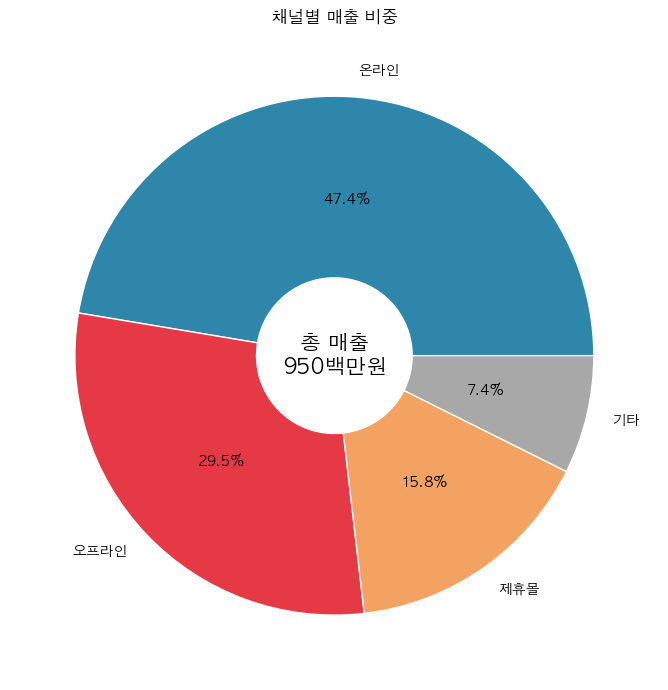

In [10]:
# Common Variations: the same data as a donut, with the total in the center
# 주요 변형: 같은 데이터를 도넛으로, 중앙에 총계 표시

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

channels = ['온라인', '오프라인', '제휴몰', '기타']
sales = [450, 280, 150, 70]
total = sum(sales)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sales, labels=channels, autopct='%1.1f%%',
       colors=['#2E86AB', '#E63946', '#F4A261', '#A8A8A8'],
       wedgeprops=dict(width=0.7, edgecolor='white'))
ax.text(0, 0, f'총 매출\n{total}백만원', ha='center', va='center', fontsize=15, fontweight='bold')
ax.set_title('채널별 매출 비중')
plt.tight_layout()
plt.show()

---
# 🧪 Small Examples · 예제

## Example 1: Treemap Basics · 예제 1: Treemap 기본

A Treemap represents each category's size as the *area* of a rectangle, making it the natural choice once you have too many categories for a Pie Chart to stay readable. It's not a built-in Matplotlib chart — it needs the separate `squarify` library.

Treemap은 각 카테고리의 크기를 사각형의 *면적*으로 표현하며, Pie Chart로는 감당이 안 될 만큼 카테고리가 많을 때 자연스러운 선택입니다. Matplotlib 내장 차트가 아니라 별도의 `squarify` 라이브러리가 필요합니다.

```
pip install squarify
```

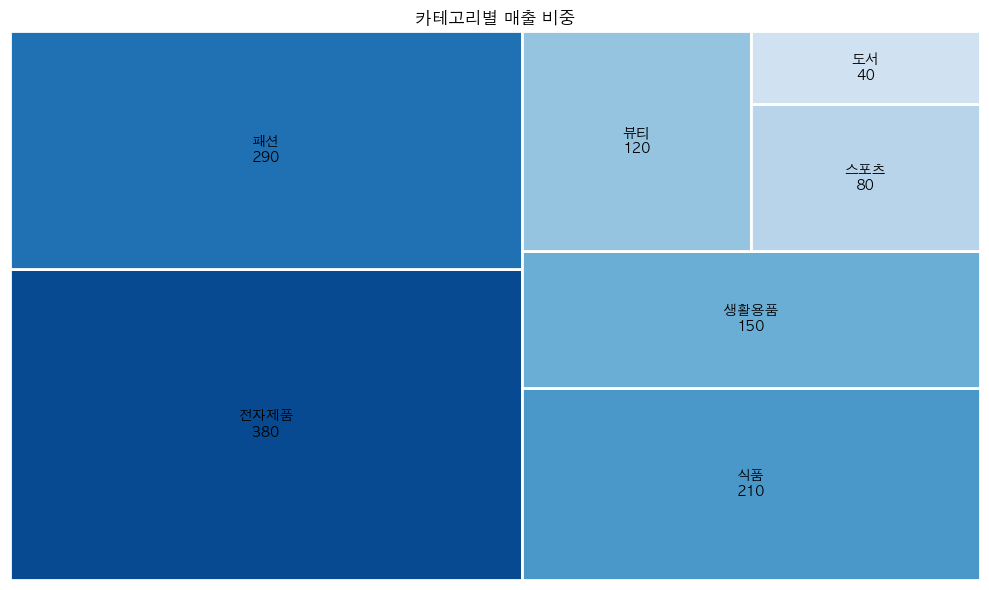

In [16]:
# Example 1: category sales as a treemap
# 예제 1: 카테고리별 매출을 treemap으로

# pip install squarify --break-system-packages   # run this once if squarify isn't installed yet

import matplotlib.pyplot as plt
import squarify

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

categories = ['전자제품', '패션', '식품', '생활용품', '뷰티', '스포츠', '도서']
sales = [380, 290, 210, 150, 120, 80, 40]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues([0.9, 0.75, 0.6, 0.5, 0.4, 0.3, 0.2])
squarify.plot(sizes=sales, label=[f'{c}\n{s}' for c, s in zip(categories, sales)],
              color=colors, ax=ax, edgecolor='white', linewidth=2,
              text_kwargs={'fontsize': 10})
ax.set_title('카테고리별 매출 비중')
ax.axis('off')
plt.tight_layout()
plt.show()

## Example 2: Treemap with a Second Encoded Variable · 예제 2: 두 번째 변수까지 인코딩한 Treemap

Area shows sales size, but color can carry an entirely different variable — here, growth rate. A diverging colormap (red = shrinking, blue = growing) makes "big but shrinking" instantly distinguishable from "small but growing fast."

면적은 매출 규모를 보여주지만, 색상으로는 완전히 다른 변수를 함께 표현할 수 있습니다 — 여기서는 성장률입니다. 발산형(diverging) 컬러맵(빨강=역성장, 파랑=성장)을 쓰면 "크지만 줄어드는" 카테고리와 "작지만 빠르게 크는" 카테고리를 한눈에 구분할 수 있습니다.

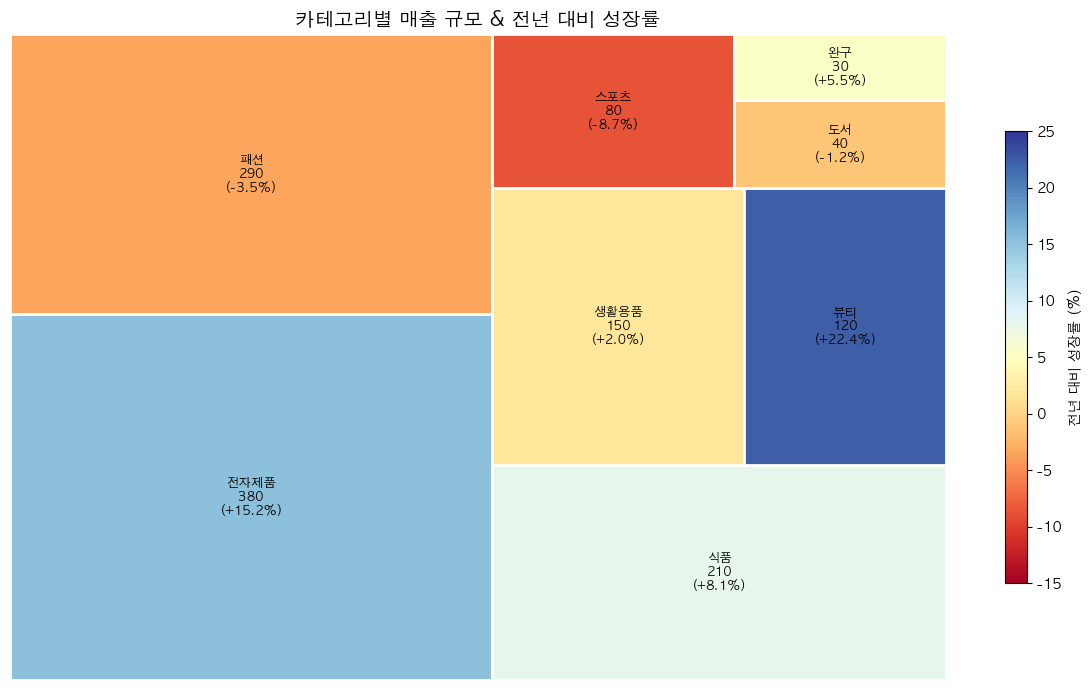

In [12]:
# Example 2: sales size (area) + growth rate (color) in one treemap
# 예제 2: 매출 규모(면적) + 성장률(색상)을 하나의 treemap에

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import squarify

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

categories = ['전자제품', '패션', '식품', '생활용품', '뷰티', '스포츠', '도서', '완구']
sales = [380, 290, 210, 150, 120, 80, 40, 30]
growth_rate = [15.2, -3.5, 8.1, 2.0, 22.4, -8.7, -1.2, 5.5]

cmap = plt.cm.RdYlBu
norm = mcolors.Normalize(vmin=-15, vmax=25)
colors = [cmap(norm(g)) for g in growth_rate]
labels = [f'{c}\n{s}\n({g:+.1f}%)' for c, s, g in zip(categories, sales, growth_rate)]

fig, ax = plt.subplots(figsize=(12, 7))
squarify.plot(sizes=sales, label=labels, color=colors, ax=ax,
              edgecolor='white', linewidth=2, text_kwargs={'fontsize': 9})
ax.set_title('카테고리별 매출 규모 & 전년 대비 성장률', fontsize=14, fontweight='bold')
ax.axis('off')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label('전년 대비 성장률 (%)')
plt.tight_layout()
plt.show()

## Example 3: Practice · 예제 3: 연습문제

Three short practices — **Part A** (Pie) needs 4 colors, **Part B** (Donut) needs a ring width, **Part C** (Treemap) needs a colormap name. Each runs without error either way; the real chart only appears once its own blanks are filled in.

세 가지 짧은 연습문제입니다 — **Part A**(Pie)는 색상 4개, **Part B**(Donut)는 고리 두께, **Part C**(Treemap)는 컬러맵 이름이 필요합니다. 각각 어떤 상태든 에러 없이 실행되며, 해당 빈칸을 채워야만 실제 차트가 나타납니다.

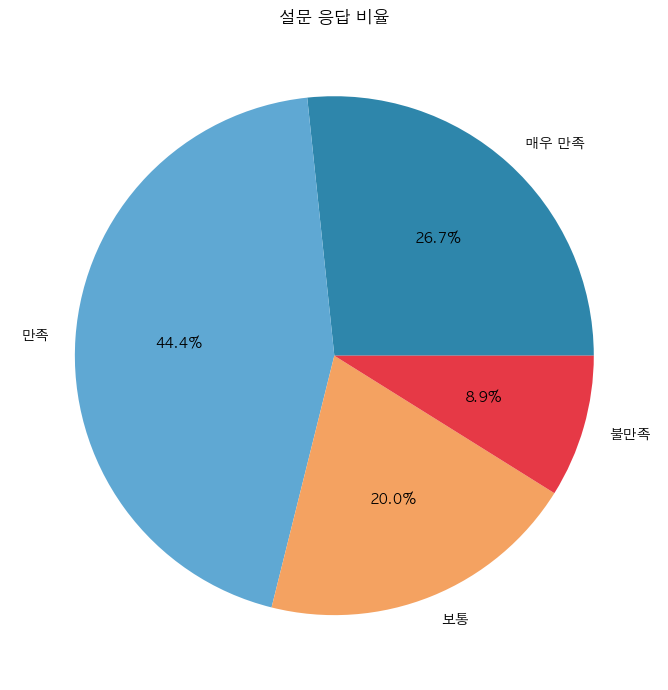

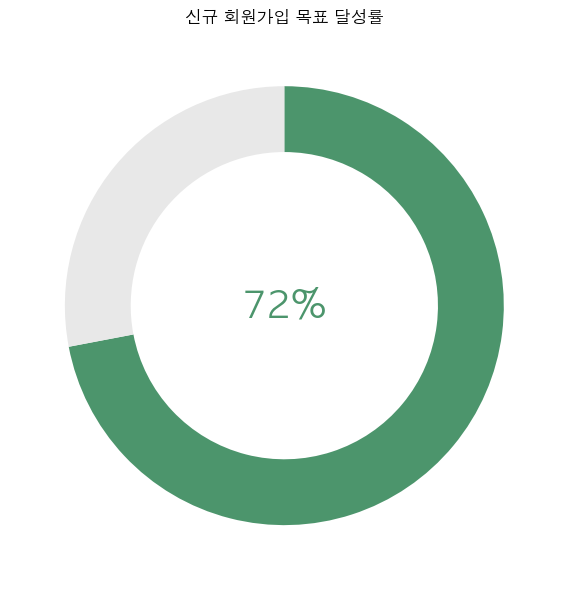

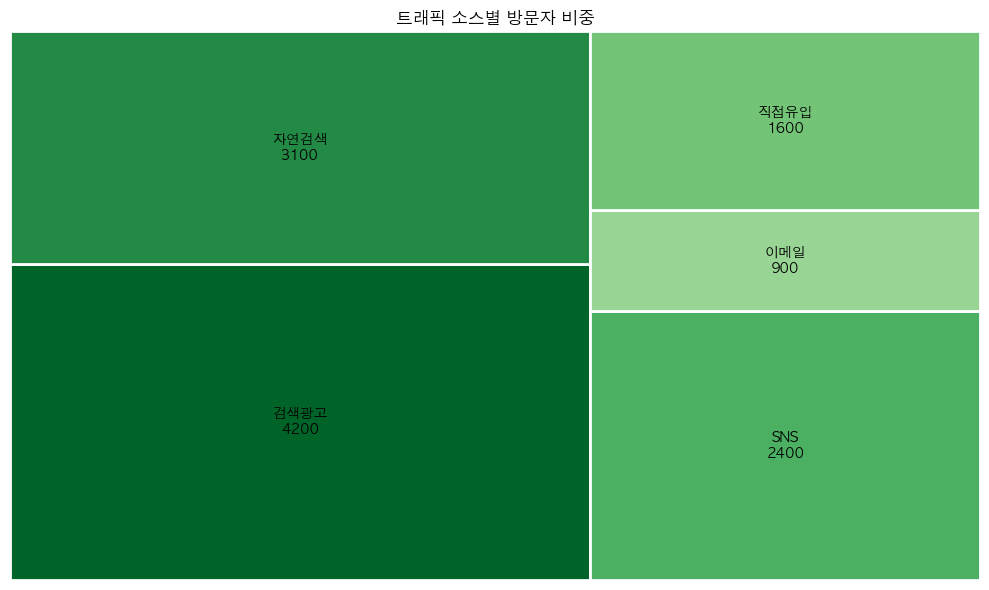

In [17]:
# Practice: fill in the blanks, then re-run this cell
# 연습문제: 빈칸을 채운 후 셀을 다시 실행하세요

import matplotlib.pyplot as plt
import squarify

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ---- Part A: pie chart of survey responses ----
# ---- Part A: 설문 응답 파이 차트 ----
responses = ['매우 만족', '만족', '보통', '불만족']
counts = [120, 200, 90, 40]

pie_colors = ['#2E86AB', '#5FA8D3', '#F4A261', '#E63946']   # TODO: a list of 4 colors, e.g. ['#2E86AB', '#5FA8D3', '#F4A261', '#E63946']

if pie_colors == "________":
    print("Part A: fill in pie_colors above, then re-run.")
    print("Part A: 위의 pie_colors를 채운 후 다시 실행하세요.")
else:
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.pie(counts, labels=responses, autopct='%1.1f%%', colors=pie_colors)
    ax.set_title('설문 응답 비율')
    plt.tight_layout()
    plt.show()

# ---- Part B: donut gauge for a signup goal ----
# ---- Part B: 신규 가입 목표 달성률 도넛 ----
target = 5000
achieved = 3600

donut_width = 0.3   # TODO: a number between 0.3 and 0.45, e.g. 0.35

if donut_width == "________":
    print("Part B: fill in donut_width above, then re-run.")
    print("Part B: 위의 donut_width를 채운 후 다시 실행하세요.")
else:
    remaining = target - achieved
    rate = achieved / target * 100
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie([achieved, remaining], colors=['#4C956C', '#E8E8E8'],
           wedgeprops=dict(width=donut_width), startangle=90, counterclock=False)
    ax.text(0, 0, f'{rate:.0f}%', ha='center', va='center', fontsize=26, fontweight='bold', color='#4C956C')
    ax.set_title('신규 회원가입 목표 달성률')
    plt.tight_layout()
    plt.show()

# ---- Part C: treemap of traffic sources ----
# ---- Part C: 트래픽 소스별 treemap ----
sources = ['검색광고', '자연검색', 'SNS', '이메일', '직접유입']
visitors = [4200, 3100, 2400, 900, 1600]

treemap_cmap = "Greens"   # TODO: a matplotlib colormap name, e.g. 'Greens'

if treemap_cmap == "________":
    print("Part C: fill in treemap_cmap above, then re-run.")
    print("Part C: 위의 treemap_cmap를 채운 후 다시 실행하세요.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.get_cmap(treemap_cmap)([0.9, 0.75, 0.6, 0.4, 0.5])
    squarify.plot(sizes=visitors, label=[f'{s}\n{v}' for s, v in zip(sources, visitors)],
                  color=colors, ax=ax, edgecolor='white', linewidth=2)
    ax.set_title('트래픽 소스별 방문자 비중')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

---
# ⚠️ Common Mistakes · 자주 하는 실수

### Mistake 1: More than 6-7 pie slices · 실수 1: 조각이 7개 이상

Once a Pie Chart has that many wedges, several become too thin to compare by eye, defeating the whole purpose of the chart.

Pie Chart의 조각이 그만큼 많아지면 여러 조각이 너무 얇아져 눈으로 비교하기 어려워지고, 차트의 목적 자체가 무색해집니다.

✅ **Fix:** Switch to a Bar Chart, or group the smallest categories into a single "Other" slice.  
✅ **해결:** Bar Chart로 전환하거나, 작은 카테고리들을 하나의 "기타"로 묶으세요.

### Mistake 2: Using a 3D Pie Chart · 실수 2: 3D Pie Chart 사용

3D perspective (common in spreadsheet tools) makes wedges in the foreground look larger than their actual value due to the viewing angle.

3D 원근감(엑셀 등에서 흔함)은 시야각 때문에 앞쪽에 있는 조각이 실제 값보다 더 커 보이게 만듭니다.

✅ **Fix:** Always use a flat 2D pie/donut — 3D introduces distortion with zero benefit.  
✅ **해결:** 항상 2D pie/donut을 사용하세요 — 3D는 아무 이득 없이 왜곡만 유발합니다.

### Mistake 3: Extreme wedgeprops width on a Donut · 실수 3: wedgeprops width를 극단적으로 설정

Setting `width` below 0.1 or above 0.8 either makes the ring nearly invisible or makes the chart look like a plain Pie again, losing the Donut's center-text advantage.

`width`를 0.1 이하나 0.8 이상으로 설정하면 고리가 거의 안 보이거나, 다시 일반 Pie처럼 보여 Donut의 중앙 텍스트 장점을 잃게 됩니다.

✅ **Fix:** Keep `width` in the 0.35-0.45 range for a balanced ring thickness.  
✅ **해결:** `width`는 0.35~0.45 범위를 권장합니다.

### Mistake 4: Center text not actually centered · 실수 4: 중앙 텍스트 좌표를 (0,0)에서 벗어나게 지정

Forgetting `ha='center', va='center'` on the `ax.text(0, 0, ...)` call leaves the KPI number looking slightly off-center, undermining the polished look a Donut is meant to have.

`ax.text(0, 0, ...)` 호출에 `ha='center', va='center'`를 빠뜨리면 KPI 숫자가 중앙에서 살짝 벗어나 보여, Donut 특유의 깔끔한 느낌이 사라집니다.

✅ **Fix:** Always pair coordinates `(0, 0)` with `ha='center', va='center'` for donut center text.  
✅ **해결:** Donut 중앙 텍스트에는 항상 좌표 `(0, 0)`과 `ha='center', va='center'`를 함께 사용하세요.

### Mistake 5: squarify not installed · 실수 5: squarify 미설치 상태로 바로 사용

Treemap isn't a built-in Matplotlib feature — trying to `import squarify` without installing it first raises `ModuleNotFoundError`.

Treemap은 Matplotlib 내장 기능이 아닙니다 — 먼저 설치하지 않고 `import squarify`를 시도하면 `ModuleNotFoundError`가 발생합니다.

✅ **Fix:** Run `pip install squarify` once before your first Treemap.  
✅ **해결:** 첫 Treemap을 그리기 전에 `pip install squarify`를 한 번 실행하세요.

### Mistake 6: Negative or zero values in a Treemap · 실수 6: sizes에 음수나 0 포함

`squarify.plot()`'s `sizes` must all be positive — negative growth rates belong in the *color* channel, never the size channel.

`squarify.plot()`의 `sizes`는 반드시 모두 양수여야 합니다 — 음의 성장률 같은 값은 크기가 아니라 반드시 *색상* 채널에 담아야 합니다.

✅ **Fix:** Keep `sizes` restricted to a genuinely positive quantity (like sales), and route anything that can go negative (like growth rate) through color instead, as Example 2 does.  
✅ **해결:** `sizes`는 매출처럼 항상 양수인 값으로만 채우고, 성장률처럼 음수가 될 수 있는 값은 Example 2처럼 색상으로 표현하세요.

### Mistake 7: Not guarding against an achievement rate over 100% · 실수 7: 달성률이 100%를 넘는 경우 처리 안 함

If `achieved` can exceed `target` (a stretch goal gets crushed, for instance), `target - achieved` goes negative, and a negative wedge value breaks the Donut gauge.

`achieved`가 `target`을 넘어설 수 있다면(예: 도전 목표를 초과 달성) `target - achieved`가 음수가 되고, 음수 조각 값은 Donut 게이지를 깨뜨립니다.

✅ **Fix:** Clamp the remaining portion with `remaining = max(0, target - achieved)` before passing it to `ax.pie()`, exactly as the Business Example below does.  
✅ **해결:** `ax.pie()`에 넘기기 전에 `remaining = max(0, target - achieved)`로 남은 값을 clamp 하세요 — 아래 Business Example처럼요.

---
# 💡 Tips · 팁
Useful tips or shortcuts · 유용한 팁과 지름길

- Before reaching for a Pie Chart, count your categories — 5 or fewer keeps it readable, more than that calls for a Bar Chart or Treemap instead. / Pie Chart를 쓰기 전에 카테고리 개수를 세어보세요 — 5개 이하면 괜찮지만, 그 이상이면 Bar Chart나 Treemap이 낫습니다.
- Reuse the same color-to-category mapping across multiple pies (like a before/after comparison) so the same category always reads as the same color. / 여러 파이 차트(전후 비교 등)에서 같은 카테고리는 항상 같은 색을 쓰도록 color 리스트를 고정해서 재사용하세요.
- The empty center of a Donut is valuable real estate — use it for the single most important number in the chart, not decoration. / Donut의 빈 중앙은 귀중한 공간입니다 — 장식이 아니라 차트에서 가장 중요한 숫자 하나를 위해 쓰세요.
- In a Treemap, let area carry the "how big" question and color carry a second question like "growing or shrinking" — trying to cram a 3rd encoded variable in usually just adds confusion. / Treemap에서는 면적이 "얼마나 큰가"를, 색상이 "성장하는가 줄어드는가" 같은 두 번째 질문을 맡게 하세요 — 3번째 인코딩 변수까지 욱여넣으면 대개 혼란만 커집니다.

---
# 🔗 Related Concepts · 관련 개념

```
   Section 6: Relationship Charts   (purpose: Relationship, Scatter/Bubble)
                ↓
   Section 7: Ratio Charts   ←  YOU ARE HERE / 지금 여기
   (purpose: Composition - "what share does each part contribute")
   Pie -> Donut -> Treemap  (more categories, more encoded variables)
                ↓
   Section 8: Composite & Special Charts
                ↓
   Section 9: Subplots & Dashboards
```

*How is today's topic connected to other concepts?* · *오늘 배운 내용이 다른 개념과 어떻게 연결되는가?*

This section directly answers Section 1's "Composition" purpose row. The Donut's "empty center as a KPI display" trick and the side-by-side dual-panel layout from the Business Example below both reappear as standard components inside Section 9's full dashboards. Treemap's color-as-second-variable technique is the same core idea as Section 8's Heatmap, just applied to rectangles of varying size instead of a uniform grid.

이 섹션은 섹션 1의 "비율" 행에 대한 직접적인 답입니다. Donut의 "빈 중앙을 KPI 표시 공간으로 쓰는" 트릭과 아래 비즈니스 예제의 좌우 2단 배치는 둘 다 섹션 9의 전체 대시보드 안에서 표준 구성요소로 다시 등장합니다. Treemap의 "색상=두 번째 변수" 기법은 섹션 8의 Heatmap과 핵심 아이디어가 동일하며, 균일한 격자 대신 크기가 다른 사각형에 적용했을 뿐입니다.

---
# 💼 Business Example · 비즈니스 예제
*How would a Business Analyst use this?* · *비즈니스 분석가는 이것을 어떻게 활용할까?*

**Scenario / 시나리오:**
It's month 9 of a 12-month annual sales target, and your manager wants a compact two-panel view: the achievement rate as a big, glanceable number, and the channel breakdown that makes up the total.

12개월 연간 매출 목표의 9개월 차입니다. 매니저가 한눈에 보이는 달성률 숫자와, 그 합계를 구성하는 채널별 내역을 함께 담은 2단 요약 화면을 요청합니다.

**To-Do / 할 일:**
- [x] Build a Donut gauge showing achievement rate as a large centered number  
달성률을 중앙에 큰 숫자로 보여주는 Donut 게이지 만들기
- [x] Compare the achievement rate against the pace-adjusted target (9/12 months elapsed)  
달성률을 경과 기간 기준 페이스 목표(9/12개월 경과)와 비교하기
- [x] Place a channel-composition Donut next to it so both views share one image  
채널 구성 Donut을 옆에 배치해 두 화면을 하나의 이미지로 합치기

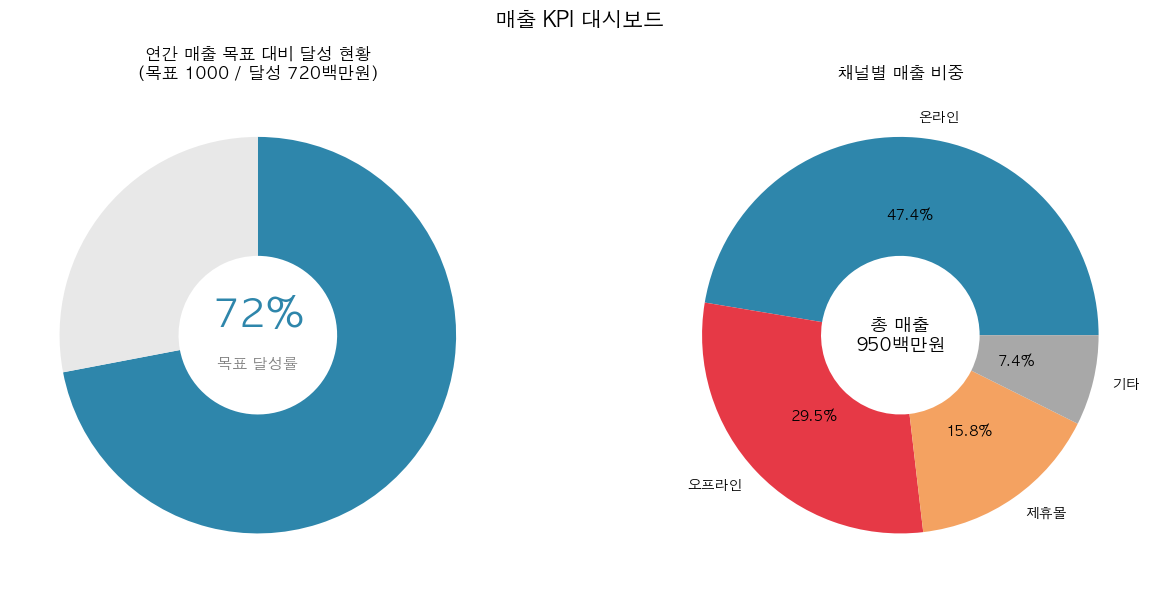

Achievement rate / 달성률: 72.0%
Pace-adjusted target (9/12 months elapsed) / 경과 기간 기준 페이스: 75.0%
-> Behind pace by 3.0pp / 페이스 기준 3.0%p 뒤처져 있음


In [24]:
# Business Example: sales KPI dashboard - achievement gauge + channel mix
# 비즈니스 예제: 매출 KPI 대시보드 - 달성률 게이지 + 채널 구성

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

target = 1000
achieved = 720
elapsed_months = 9   # 9 of 12 months have passed / 12개월 중 9개월 경과
remaining = max(0, target - achieved)   # guard against achieved > target / 달성률 100% 초과 시 방어 코드
achievement_rate = achieved / target * 100
expected_rate = elapsed_months / 12 * 100   # "on-pace" rate given time elapsed

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# (1) achievement gauge
axes[0].pie([achieved, remaining], colors=['#2E86AB', '#E8E8E8'],
            wedgeprops=dict(width=0.6), startangle=90, counterclock=False)
axes[0].text(0, 0.1, f'{achievement_rate:.0f}%', ha='center', va='center',
             fontsize=28, fontweight='bold', color='#2E86AB')
axes[0].text(0, -0.15, '목표 달성률', ha='center', va='center', fontsize=11, color='gray')
axes[0].set_title(f'연간 매출 목표 대비 달성 현황\n(목표 {target} / 달성 {achieved}백만원)')

# (2) channel composition
channels = ['온라인', '오프라인', '제휴몰', '기타']
sales = [450, 280, 150, 70]
axes[1].pie(sales, labels=channels, autopct='%1.1f%%',
            colors=['#2E86AB', '#E63946', '#F4A261', '#A8A8A8'],
            wedgeprops=dict(width=0.6))
axes[1].text(0, 0, f'총 매출\n{sum(sales)}백만원', ha='center', va='center',
             fontsize=13, fontweight='bold')
axes[1].set_title('채널별 매출 비중')

fig.suptitle('매출 KPI 대시보드', fontsize=15, fontweight='bold')
plt.tight_layout()
# fig.savefig('sales_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Achievement rate / 달성률: {achievement_rate:.1f}%")
print(f"Pace-adjusted target ({elapsed_months}/12 months elapsed) / 경과 기간 기준 페이스: {expected_rate:.1f}%")
if achievement_rate >= expected_rate:
    print(f"-> Ahead of pace by {achievement_rate - expected_rate:.1f}pp / 페이스 기준 {achievement_rate - expected_rate:.1f}%p 앞서 있음")
else:
    print(f"-> Behind pace by {expected_rate - achievement_rate:.1f}pp / 페이스 기준 {expected_rate - achievement_rate:.1f}%p 뒤처져 있음")

---
# 📝 Summary · 요약
*Write today's concept in 3~5 sentences.* · *오늘 배운 개념을 3~5문장으로 정리하세요.*

A Pie Chart shows each category's share of a whole using wedge angle, but it only stays readable with about 5-6 categories or fewer, since the human eye compares angle and area far less precisely than length. A Donut Chart is the same underlying `ax.pie()` call with `wedgeprops=dict(width=...)`, and its empty center is prime space for displaying a single important KPI number via `ax.text(0, 0, ...)`. A Treemap solves the "too many categories" problem by representing size as rectangle area (via the separate `squarify` library) instead of angle, and can carry a 2nd variable like growth rate through color — turning "which categories are big" and "which are growing" into one glance. Across all three, remember that size/area values must stay positive, and that a variable which can go negative (like growth rate) belongs in color, never in size.

Pie Chart는 부채꼴 각도로 각 카테고리가 전체에서 차지하는 비중을 보여주지만, 사람의 눈이 각도와 넓이를 길이보다 훨씬 부정확하게 비교하기 때문에 카테고리가 5~6개 이하일 때만 읽기 쉽습니다. Donut Chart는 같은 `ax.pie()` 호출에 `wedgeprops=dict(width=...)`만 더한 것이며, 빈 중앙은 `ax.text(0, 0, ...)`로 중요한 KPI 숫자 하나를 표시하기 좋은 공간입니다. Treemap은 각도 대신 사각형 면적으로 크기를 표현해(별도의 `squarify` 라이브러리 필요) "카테고리가 너무 많은" 문제를 해결하며, 색상으로 성장률 같은 2번째 변수까지 함께 담아 "어느 게 큰가"와 "어느 게 성장하는가"를 한눈에 보여줄 수 있습니다. 세 차트 모두에서, 크기/면적 값은 반드시 양수여야 하고, 음수가 될 수 있는 변수(성장률 등)는 크기가 아니라 항상 색상에 담아야 한다는 점을 기억하세요.

---
# 📌 One Sentence Summary · 한 줄 요약
Today's topic in ONE sentence. · 오늘의 주제를 한 문장으로.

> Pie, Donut, and Treemap all answer "what share does each part contribute," but Pie and Donut only stay readable with a handful of categories, while Treemap trades angle for area to handle many categories and can even fold in a second variable through color.

> Pie, Donut, Treemap은 모두 "각 부분이 전체에서 차지하는 비중은?"에 답하지만, Pie와 Donut은 카테고리가 소수일 때만 읽기 쉽고, Treemap은 각도 대신 면적을 써서 많은 카테고리를 다루며 색상으로 두 번째 변수까지 담을 수 있다.

---
# ❓ Review Questions · 복습 문제

**Q1.** Why does a Pie Chart become hard to read once it has 7 or more slices, and what would you use instead?
Pie Chart는 조각이 7개 이상이 되면 왜 읽기 어려워지며, 대신 무엇을 사용하겠는가?

**Q2.** What single parameter turns a Pie Chart into a Donut Chart, and what does its value control?
어떤 파라미터 하나가 Pie Chart를 Donut Chart로 바꾸며, 그 값은 무엇을 조절하는가?

**Q3.** In a Treemap, what does area represent, and what can color represent in addition?
Treemap에서 면적은 무엇을 나타내며, 색상으로는 추가로 무엇을 나타낼 수 있는가?

**Q4.** Why must a Treemap's `sizes` values always be positive, and where should a value that can be negative (like a growth rate) go instead?
Treemap의 `sizes` 값은 왜 항상 양수여야 하며, 음수가 될 수 있는 값(성장률 등)은 대신 어디에 담아야 하는가?

**Q5.** You need to show "72% of the annual goal achieved" as a single glanceable number inside a chart. Which chart from this section fits best, and why?
"연간 목표의 72% 달성"을 차트 안의 한눈에 보이는 숫자로 보여줘야 한다. 이 섹션의 어떤 차트가 가장 적합하며, 그 이유는 무엇인가?

---
*📅 Try answering these again in a few days.* · *📅 며칠 후에 다시 답해보세요.*